## Bethe-Bloch Simulation

In [8]:
import numpy as np
import scipy.constants as con

def beta(T: float, E_0: float):
    """
    :T: Kinetische Energie des Teilchens in eV
    :E_0: Ruheenergie des Teilchens in eV
    """
    gamma = (T/E_0)+1
    return np.sqrt(1-1/gamma**2)

class Material:
    def __init__(self, Z, A, I, n):
        """
        :Z: Ladungszahl
        :A: Massenzahl
        :I: mittlere Ionisationsenergy (in J)
        :n: Dichte in g/cm³
        """
        self.I = I
        self.n_e = Z*n*1e3/A/con.u

Au = Material(79, 197, 790*con.e, 19.32)
Si = Material(14, 28, 173*con.e, 2.33)

def Bethe(target: Material, E:float, z=2, E0=3728e6):
    """
    :target: Zielmaterial
    :E: Kinetische Energie des Teilchens in eV
    :z: Ladungszahl des Teilchens
    :E0: Ruheenergie des Teilchens in eV
    """
    n = target.n_e
    I = target.I
    B2 = beta(E, E0)**2
    a = (4*np.pi*n*z**2)/(con.m_e*con.c**2*B2)
    b =(con.e**2/(4*np.pi*con.epsilon_0))**2
    c = np.log((2*con.m_e*con.c**2*B2)/(I*(1-B2))) - B2
    return -a * b * c

def Reichweite(target: Material, E: float, dx=1e-6, Elim=1):
    """
    :target: Materialeigenschaften des Zielmaterials
    :E: Kinetische Energie des Teilchens in eV
    :dx: Schrittweite in m
    """
    l = 0
    while E > Elim: # in eV
        lost = Bethe(target, E) / con.e * dx # Energieverlust in eV
        E -= abs(lost)
        l += dx
    return l

In [2]:
E = np.logspace(4, 8, endpoint=True)

vBethe = np.vectorize(Bethe)
vReich = np.vectorize(Reichweite)

dEdx = vBethe(Si, E)
rw = vReich(Si, E, dx=1e-6)

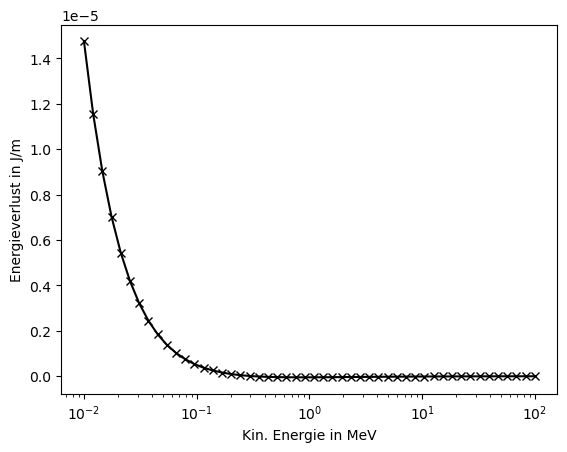

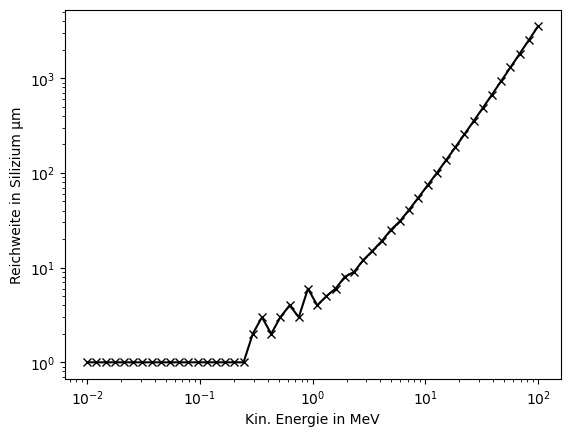

In [10]:
import matplotlib.pyplot as plt

plt.plot(E/1e6, dEdx, 'x-k')
plt.xscale('log')
plt.ylabel('Energieverlust in J/m')
plt.xlabel('Kin. Energie in MeV')

fig, ax = plt.subplots()
ax.plot(E/1e6, rw/1e-6, 'x-k')


ax.set_xscale('log')
ax.set_yscale('log')

ax.set_xlabel('Kin. Energie in MeV')
ax.set_ylabel('Reichweite in Silizium µm')


plt.show()

## Linearitätsprüfung

In [4]:
import pandas as pd



## $\alpha$-Spektrum fits

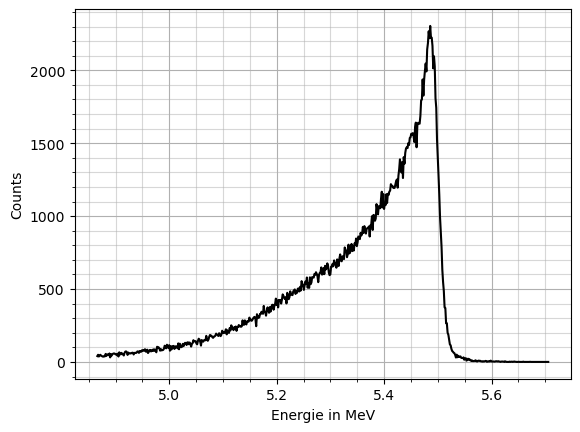

In [23]:
from scipy.optimize import curve_fit

def gaussian(x, mu, sig, y0, A):
    return A*np.exp(-(x-mu)**2/(2*sig**2))+y0

skiprows = 3499#bis 350 eh keine Werte und die 99, damit ich einen Verschub um 400 und eine Nullindizierung habe
spektrum = np.loadtxt('../Messdaten/19012026_Halbleiter/21_1h10_Alpha.TKA', skiprows=skiprows)
#neue Energieachse erstellen über Fixpunkt bei dem Hauptpeak und der Energie/Kanal Zuordnung aus der Linearitätsprüfung
max = 3940 - (skiprows +1) # weil beim Detektor mit 1 angefangen wird
Emax = 5.4857 #MeV
m = 1.0/710.0

energie = []

for i in range(len(spektrum)):
    energie.append(Emax + m*(i-max))

energie = np.array(energie)

fig, ax = plt.subplots()
ax.plot(energie, spektrum, '-k')
ax.minorticks_on()
ax.grid(which='major')
ax.grid(which='minor', alpha=0.5)
ax.set_xlabel('Energie in MeV')
ax.set_ylabel('Counts')

plt.show()

### Fit des Hauptmaximums durch eine Gaußkurve

[5.48587315e+00 1.43200239e-02 7.91112628e+00 2.26388252e+03]


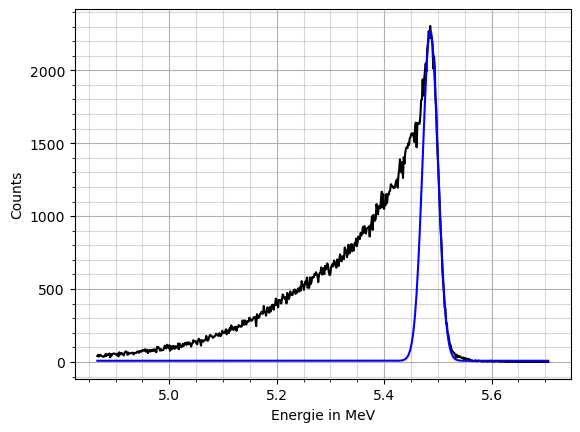

In [31]:
bereich1 = np.where(5.485<energie)

guess = [5.4857, 0.014, 0, 2260]
popt1, pcov1 = curve_fit(gaussian, energie[bereich1], spektrum[bereich1], guess)
print(popt1)

fig, ax = plt.subplots()
ax.plot(energie, spektrum, '-k')
ax.plot(energie, gaussian(energie,*popt1), '-b')
ax.minorticks_on()
ax.grid(which='major')
ax.grid(which='minor', alpha=0.5)
ax.set_xlabel('Energie in MeV')
ax.set_ylabel('Counts')

plt.show()

Abziehen des ersten Fits und dann Fit des Maximums bei 5.443MeV

[ 5.44822536e+00  1.48116226e-02 -3.80450548e+00  1.51017753e+03]


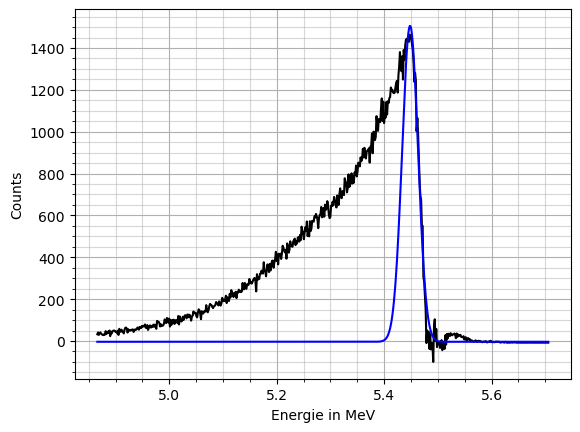

In [33]:
spektrum2 = spektrum - gaussian(energie, *popt1)

bereich2 = np.where(5.44<energie)

guess2 = [5.443, 0.05, 0, 1400]
popt2, pcov2 = curve_fit(gaussian, energie[bereich2], spektrum2[bereich2], guess2)
print(popt2)

fig, ax = plt.subplots()
ax.plot(energie, spektrum2, '-k')
ax.plot(energie, gaussian(energie,*popt2), '-b')
ax.minorticks_on()
ax.grid(which='major')
ax.grid(which='minor', alpha=0.5)
ax.set_xlabel('Energie in MeV')
ax.set_ylabel('Counts')

plt.show()

Abziehen des zweiten Fits und dann Fit des dritten Peaks bei 5.388MeV

[ 5.40369755e+00  2.02065091e-02 -5.77763994e+00  1.21214739e+03]


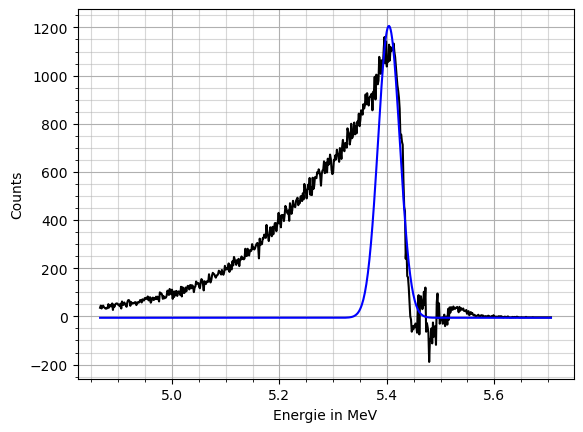

In [35]:
spektrum3 = spektrum2 - gaussian(energie, *popt2)

bereich3 = np.where(5.387<energie)

guess3 = [5.388, 0.014, 0, 1100]
popt3, pcov3 = curve_fit(gaussian, energie[bereich3], spektrum3[bereich3], guess3)
print(popt3)

fig, ax = plt.subplots()
ax.plot(energie, spektrum3, '-k')
ax.plot(energie, gaussian(energie,*popt3), '-b')
ax.minorticks_on()
ax.grid(which='major')
ax.grid(which='minor', alpha=0.5)
ax.set_xlabel('Energie in MeV')
ax.set_ylabel('Counts')

plt.show()

zusätzlicher Fit der Peaks rechts bei 5.512MeV und 5.5443 MeV